**1.Data Collection and Preprocessing**

The Individual Household Electric Power Consumption dataset from the UCI Machine Learning Repository / Kaggle is a widely cited, gold-standard dataset for household energy forecasting. It provides high-resolution time-series data suitable for both classical and machine-learning models.

In [ ]:
# Importing necessary libraries

# Importing NumPy for numerical operations
import numpy as np

# Importing Pandas for data manipulation and analysis
import pandas as pd

# Importing Matplotlib for data visualization
import matplotlib.pyplot as plt

# Importing Seaborn for enhanced data visualization
import seaborn as sns

# Importing seasonal decomposition from statsmodels for time series decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Importing functions to plot autocorrelation and partial autocorrelation from statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Importing mean squared error for model evaluation from sklearn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Importing datetime for date and time manipulation
from datetime import datetime

# Importing warnings library to suppress warnings
import warnings
warnings.filterwarnings('ignore')  # Ignoring all warnings for cleaner output

In [ ]:
# Reading the dataset from a CSV file into a DataFrame using Pandas
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/household_power_consumption.txt', sep=';')

# Displaying the first few rows of the DataFrame to get an overview of the data
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [ ]:
# Checking the dimensions of the DataFrame (number of rows and columns)
df.shape

(2075259, 9)

In [ ]:
import pandas as pd
import numpy as np

df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.isnull().sum()
df = df.dropna(subset=['Global_active_power'])
df = df.drop_duplicates()
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   date_time              datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 126.7 MB


2. **FEATURE ENGINEERING**

In [ ]:
df.index = pd.to_datetime(df.index)
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_month'] = df.index.day
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_24'] = df['Global_active_power'].shift(24)
df['rolling_mean_24'] = df['Global_active_power'].rolling(window=24).mean()
df['rolling_std_24'] = df['Global_active_power'].rolling(window=24).std()
df = df.dropna()
df.head()
df.columns
df.describe()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,date_time,hour,day_of_week,month,day_of_month,week_of_year,is_weekend,lag_1,lag_24,rolling_mean_24,rolling_std_24
count,2.047594e+06,2.047594e+06,2.047594e+06,2.047594e+06,2.047594e+06,2.047594e+06,2.047594e+06,2047594,2047594.0,2047594.0,2047594.0,2047594.0,2047594.0,2047594.0,2.047594e+06,2.047594e+06,2.047594e+06,2.047594e+06
mean,1.090858e+00,1.236698e-01,2.408414e+02,4.624540e+00,1.119941e+00,1.296021e+00,6.455857e+00,2008-12-02 02:16:33.872554752,0.0,3.0,1.0,1.0,1.0,0.0,1.090868e+00,1.091193e+00,1.091003e+00,2.759526e-01
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:48:00,0.0,3.0,1.0,1.0,1.0,0.0,7.600000e-02,7.600000e-02,7.900000e-02,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-10 07:54:15,0.0,3.0,1.0,1.0,1.0,0.0,3.080000e-01,3.080000e-01,3.275000e-01,4.952733e-02
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-11-30 02:13:30,0.0,3.0,1.0,1.0,1.0,0.0,6.020000e-01,6.020000e-01,6.902500e-01,9.903833e-02
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-11-23 21:32:45,0.0,3.0,1.0,1.0,1.0,0.0,1.528000e+00,1.528000e+00,1.566667e+00,3.672499e-01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00,0.0,3.0,1.0,1.0,1.0,0.0,1.112200e+01,1.112200e+01,8.108167e+00,3.307819e+00
std,1.056475e+00,1.126961e-01,3.239373e+00,4.440867e+00,6.146691e+00,5.814856e+00,8.436343e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.056487e+00,1.056915e+00,9.648998e-01,3.426976e-01


Mean: 1.090857879052195
Min: 0.076
Max: 11.122
Std: 1.0564751252631788


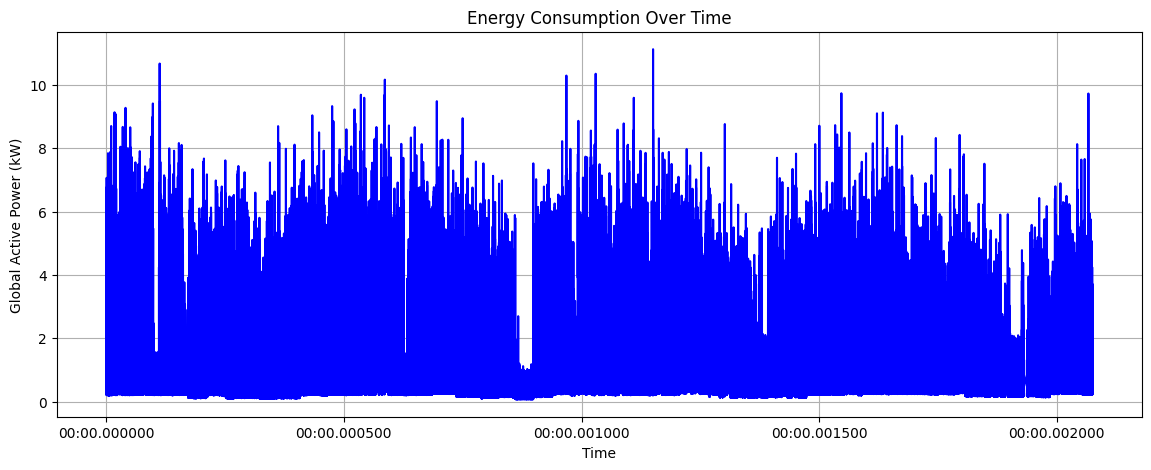

In [ ]:
# Basic statistical summary
df[['Global_active_power', 'Voltage', 'Global_intensity']].describe()
print("Mean:", df['Global_active_power'].mean())
print("Min:", df['Global_active_power'].min())
print("Max:", df['Global_active_power'].max())
print("Std:", df['Global_active_power'].std())
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Global_active_power'], color='blue')
plt.title('Energy Consumption Over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.show()

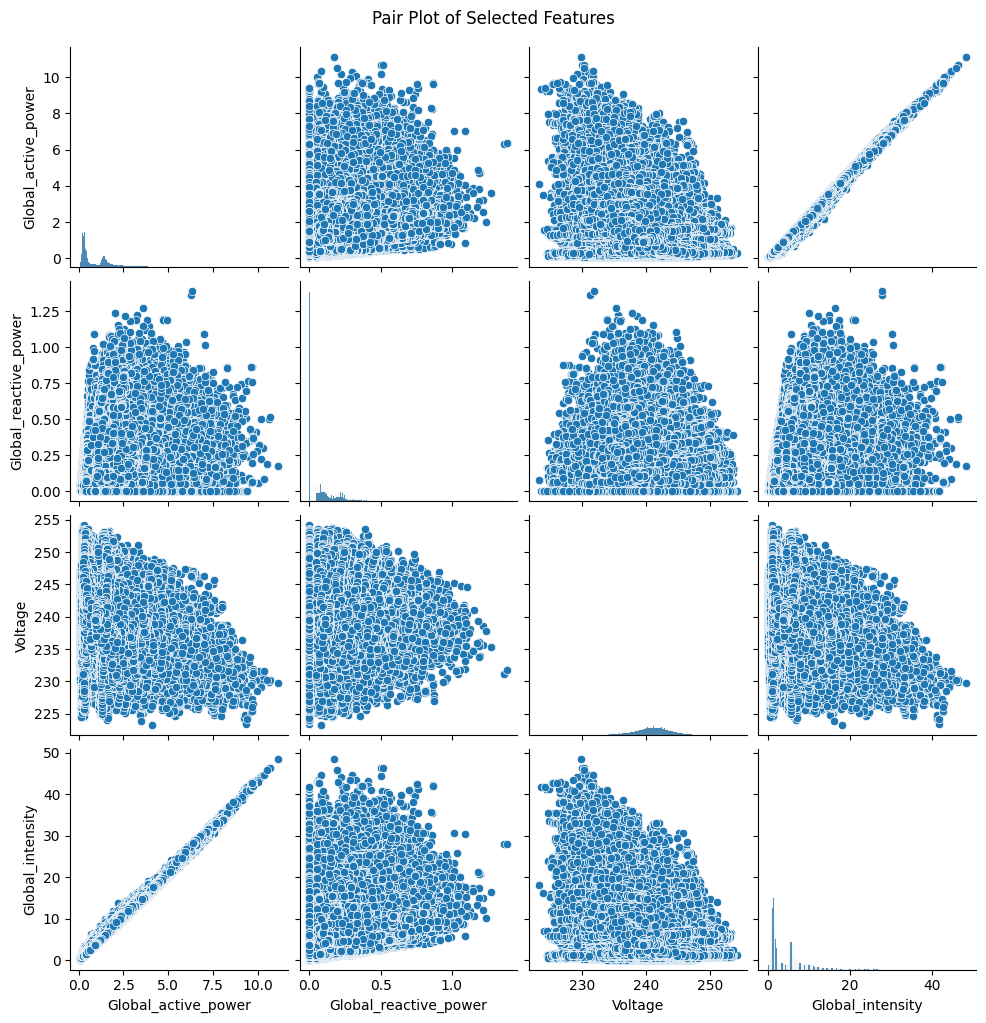

In [ ]:
# Creating a pairplot of selected features using Seaborn

# Plotting pairplot for selected features
sns.pairplot(df[['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']])

# Adding overall title with adjusted vertical position
plt.suptitle('Pair Plot of Selected Features', y=1.02)

# Displaying the plot
plt.show()

3. **EXPLORATORY DATA ANALYSIS(EDA)**

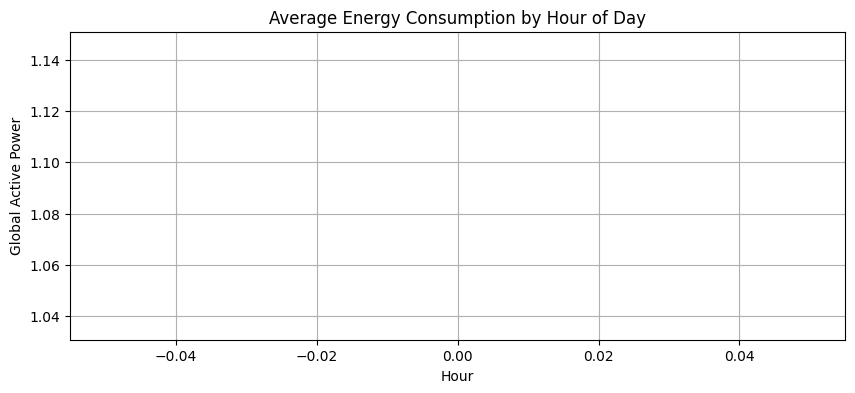

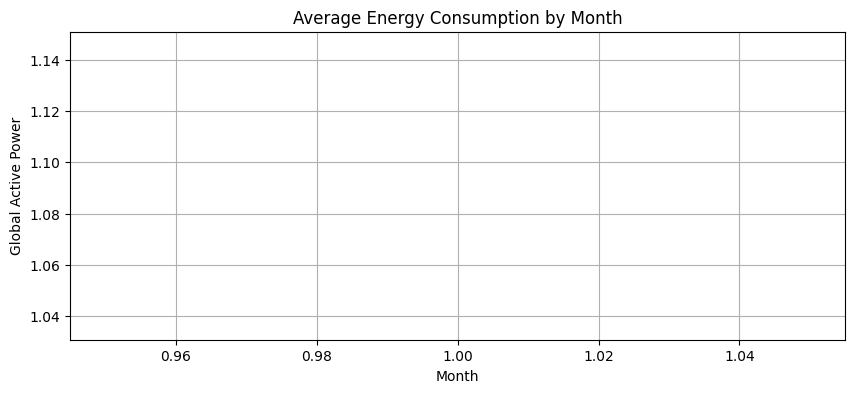

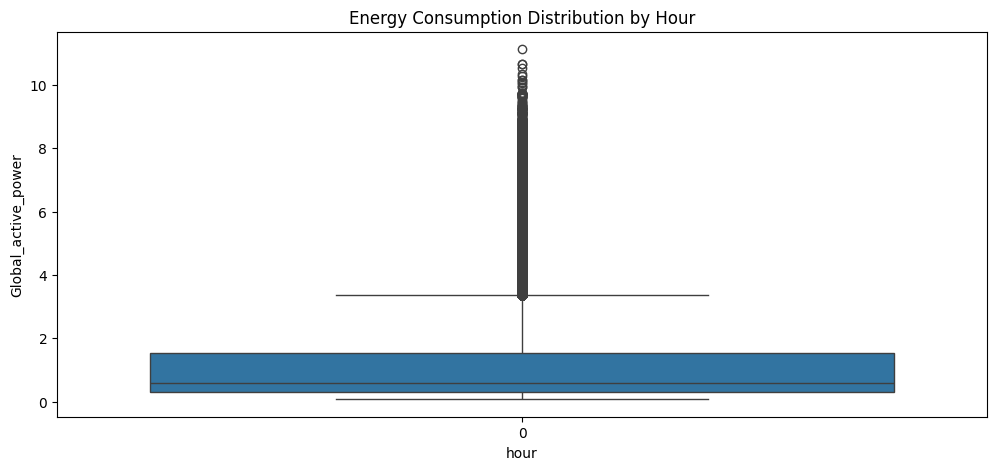

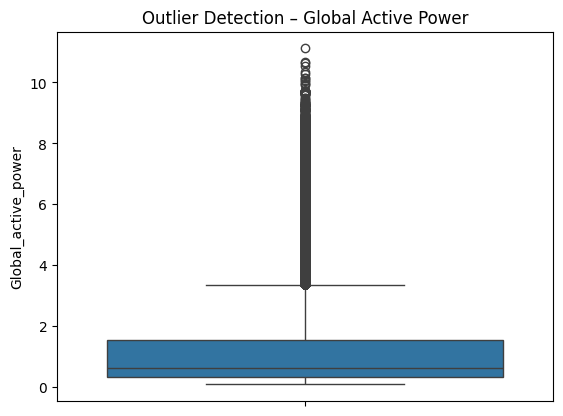

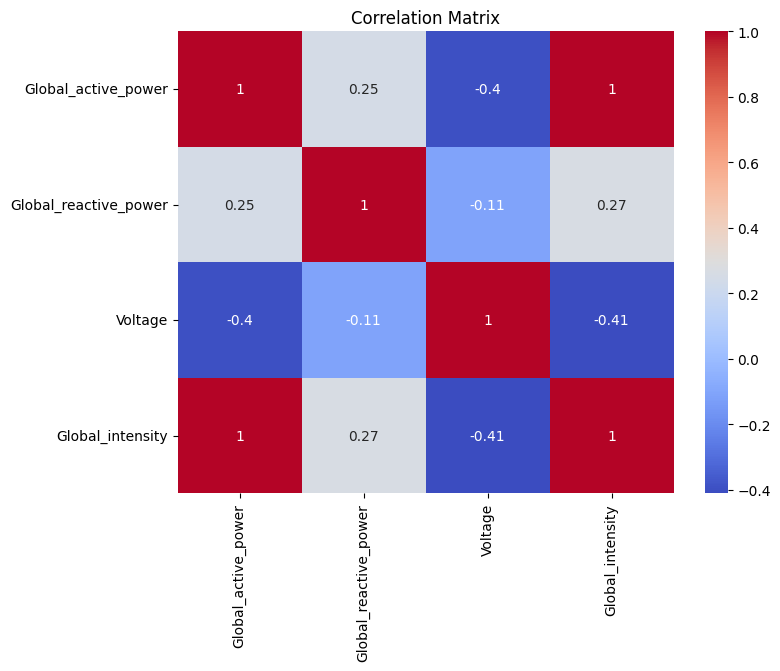

In [ ]:
df.groupby(df.index.hour)['Global_active_power'].mean().plot(figsize=(10,4))
plt.title('Average Energy Consumption by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Global Active Power')
plt.grid(True)
plt.show()

df.groupby(df.index.month)['Global_active_power'].mean().plot(figsize=(10,4))
plt.title('Average Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Global Active Power')
plt.grid(True)
plt.show()

df['hour'] = df.index.hour

plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='Global_active_power', data=df)
plt.title('Energy Consumption Distribution by Hour')
plt.show()

sns.boxplot(y=df['Global_active_power'])
plt.title('Outlier Detection – Global Active Power')
plt.show()

corr = df[['Global_active_power', 'Global_reactive_power',
           'Voltage', 'Global_intensity']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()




4. **TRAIN TEST SPLIT**

In [ ]:
df = df.sort_index()
split_ratio = 0.8
split_index = int(len(df) * split_ratio)
train = df.iloc[:split_index]
test  = df.iloc[split_index:]
print("Training data ends at:", train.index[-1])
print("Testing data starts at:", test.index[0])
print("Training set size:", train.shape)
print("Testing set size:", test.shape)
X_train = train.drop(columns=['Global_active_power'])
y_train = train['Global_active_power']

X_test = test.drop(columns=['Global_active_power'])
y_test = test['Global_active_power']


Training data ends at: 1970-01-01 00:00:00.001650977
Testing data starts at: 1970-01-01 00:00:00.001650978
Training set size: (1638075, 18)
Testing set size: (409519, 18)


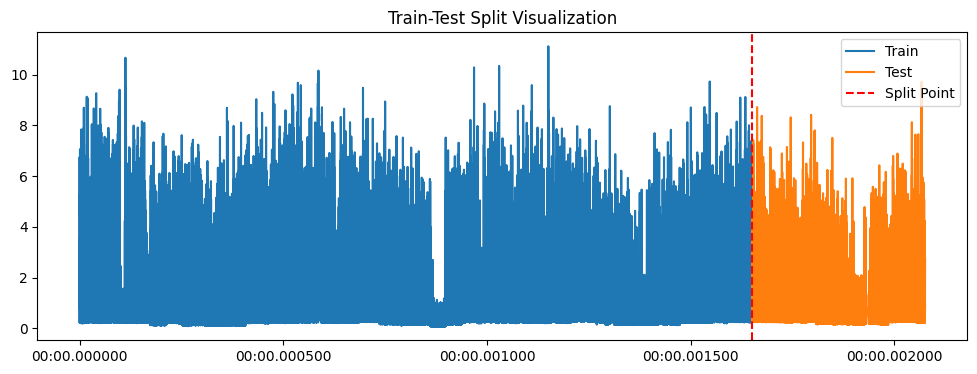

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(train.index, y_train, label='Train')
plt.plot(test.index, y_test, label='Test')
plt.axvline(test.index[0], color='red', linestyle='--', label='Split Point')
plt.legend()
plt.title('Train-Test Split Visualization')
plt.show()


5. **MODEL SELECTION&IMPLEMENTATION**

In [ ]:
X_train_lr = train.drop(columns=['Global_active_power', 'date_time'])
y_train_lr = train['Global_active_power']

X_test_lr = test.drop(columns=['Global_active_power', 'date_time'])
y_test_lr = test['Global_active_power']

from sklearn.preprocessing import StandardScaler

scaler_lr = StandardScaler()

X_train_lr = scaler_lr.fit_transform(X_train_lr)
X_test_lr = scaler_lr.transform(X_test_lr)

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
lr_preds = lr_model.predict(X_test_lr)

In [ ]:
X_train_rf = train.drop(columns=['Global_active_power', 'date_time'])
y_train_rf = train['Global_active_power']

X_test_rf = test.drop(columns=['Global_active_power', 'date_time'])
y_test_rf = test['Global_active_power']
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train_rf, y_train_rf)
rf_preds = rf_model.predict(X_test_rf)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_lstm = MinMaxScaler()

train_scaled = scaler_lstm.fit_transform(train[['Global_active_power']])
test_scaled = scaler_lstm.transform(test[['Global_active_power']])

def create_sequences(data, look_back=30):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X_train_lstm, y_train_lstm = create_sequences(train_scaled)
X_test_lstm, y_test_lstm = create_sequences(test_scaled)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(50, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm),
    shuffle=False
)
lstm_preds = lstm_model.predict(X_test_lstm)
lstm_preds = scaler_lstm.inverse_transform(lstm_preds)


Epoch 1/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 305s 6ms/step - loss: 0.0011 - val_loss: 3.9145e-04
Epoch 2/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 318s 6ms/step - loss: 8.3482e-04 - val_loss: 3.8979e-04
Epoch 3/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 322s 6ms/step - loss: 8.2178e-04 - val_loss: 3.9361e-04
Epoch 4/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 303s 6ms/step - loss: 8.1362e-04 - val_loss: 3.9107e-04
Epoch 5/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 299s 6ms/step - loss: 8.0851e-04 - val_loss: 3.9138e-04
Epoch 6/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 298s 6ms/step - loss: 8.0360e-04 - val_loss: 3.8844e-04
Epoch 7/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 299s 6ms/step - loss: 7.9604e-04 - val_loss: 3.8156e-04
Epoch 8/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 326s 6ms/step - loss: 7.8627e-04 - val_loss: 3.8356e-04
Epoch 9/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 304s 6ms/step - loss: 7.7636e-04 - val_loss: 3.7966e-04
Epoch 10/10
51189/51189 ━━━━━━━━━━━━━━━━━━━━ 300s 6ms/step - loss: 7.7011e-04 - val_loss: 3.7891e-04
127

In [ ]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,355 (122.48 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,904 (81.66 KB)

6. **MODEL EVALUATION**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_preds)

rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_preds)

lstm_mae, lstm_rmse, lstm_r2 = evaluate_model(
    y_test_lstm,
    lstm_preds.flatten()
)
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'MAE': [lr_mae, rf_mae, lstm_mae],
    'RMSE': [lr_rmse, rf_rmse, lstm_rmse],
    'R² Score': [lr_r2, rf_r2, lstm_r2]
})

print(results)
best_model = results.sort_values(by='RMSE').iloc[0]
print("Best Performing Model:")
print(best_model)


               Model       MAE      RMSE    R² Score
0  Linear Regression  0.023958  0.039003    0.998106
1      Random Forest  0.017432  0.032960    0.998647
2               LSTM  0.919466  1.224907 -226.964530
Best Performing Model:
Model       Random Forest
MAE              0.017432
RMSE              0.03296
R² Score         0.998647
Name: 1, dtype: object


7. **VISUALIZATION OF RESULTS**

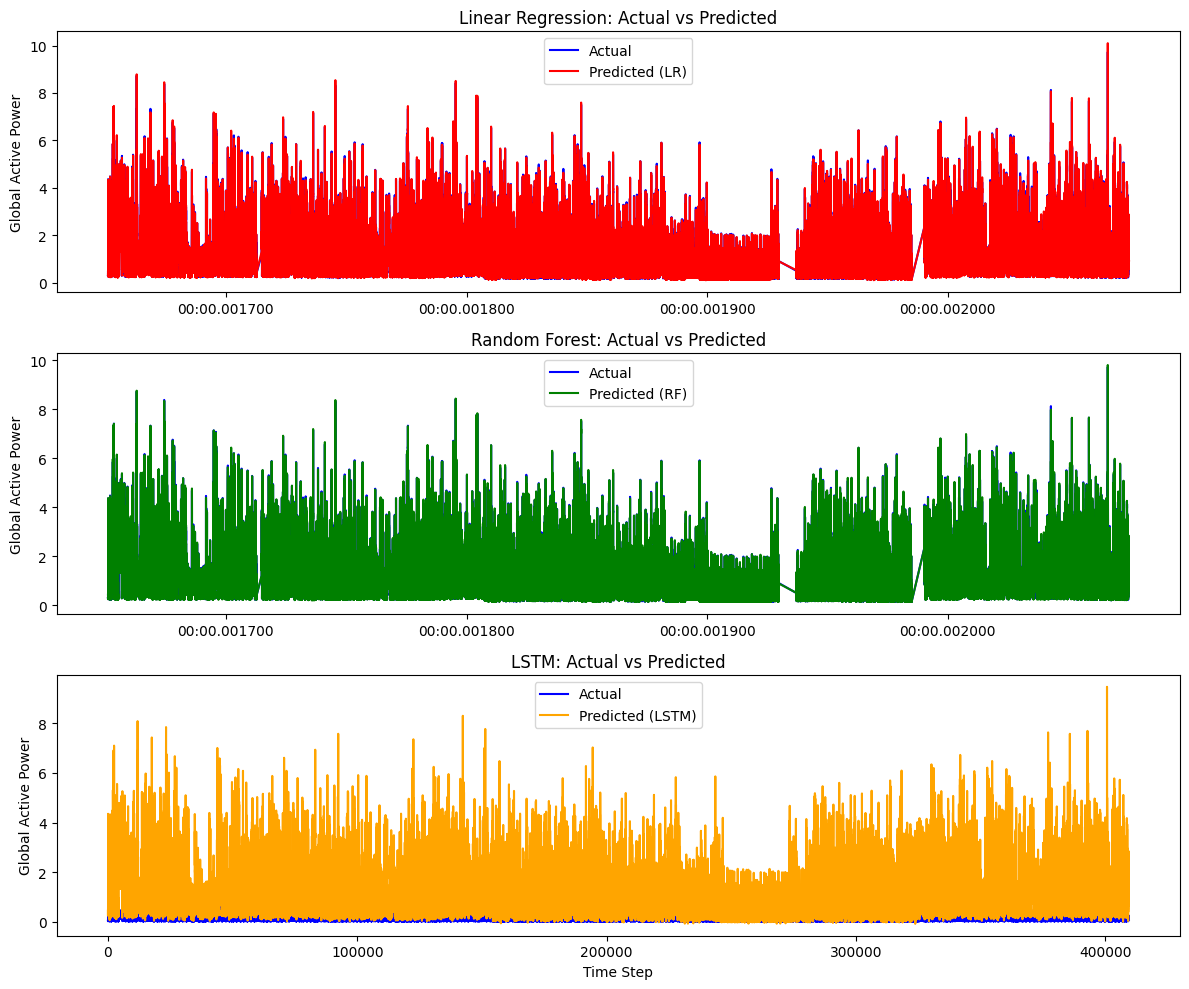

In [ ]:
import matplotlib.pyplot as plt

# Create one figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# ---- Linear Regression ----
axes[0].plot(y_test.index, y_test, label='Actual', color='blue')
axes[0].plot(y_test.index, lr_preds, label='Predicted (LR)', color='red')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_ylabel('Global Active Power')
axes[0].legend()

# ---- Random Forest ----
axes[1].plot(y_test.index, y_test, label='Actual', color='blue')
axes[1].plot(y_test.index, rf_preds, label='Predicted (RF)', color='green')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_ylabel('Global Active Power')
axes[1].legend()

# ---- LSTM ----
axes[2].plot(y_test_lstm, label='Actual', color='blue')
axes[2].plot(lstm_preds, label='Predicted (LSTM)', color='orange')
axes[2].set_title('LSTM: Actual vs Predicted')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Global Active Power')
axes[2].legend()

# Improve spacing
plt.tight_layout()
plt.show()



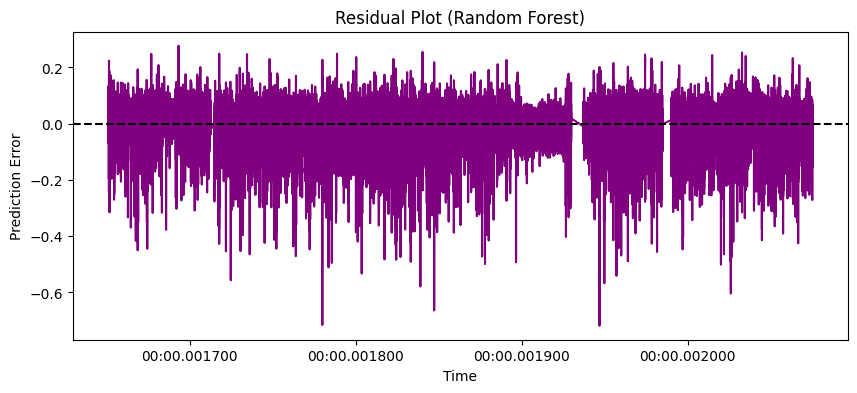

In [ ]:
residuals = y_test - rf_preds

plt.figure(figsize=(10,4))
plt.plot(residuals, color='purple')
plt.axhline(0, linestyle='--', color='black')

plt.title('Residual Plot (Random Forest)')
plt.xlabel('Time')
plt.ylabel('Prediction Error')
plt.show()


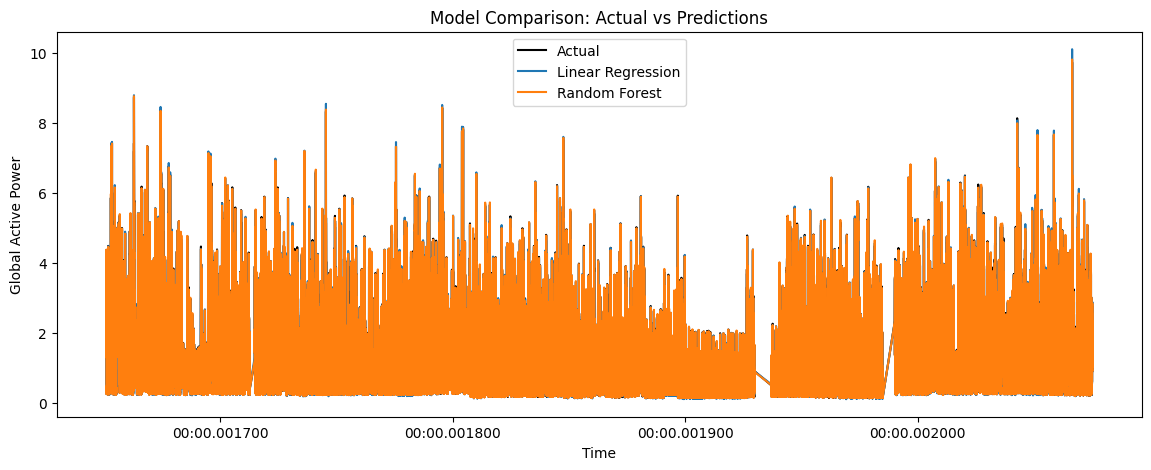

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, lr_preds, label='Linear Regression')
plt.plot(y_test.index, rf_preds, label='Random Forest')

plt.title('Model Comparison: Actual vs Predictions')
plt.xlabel('Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


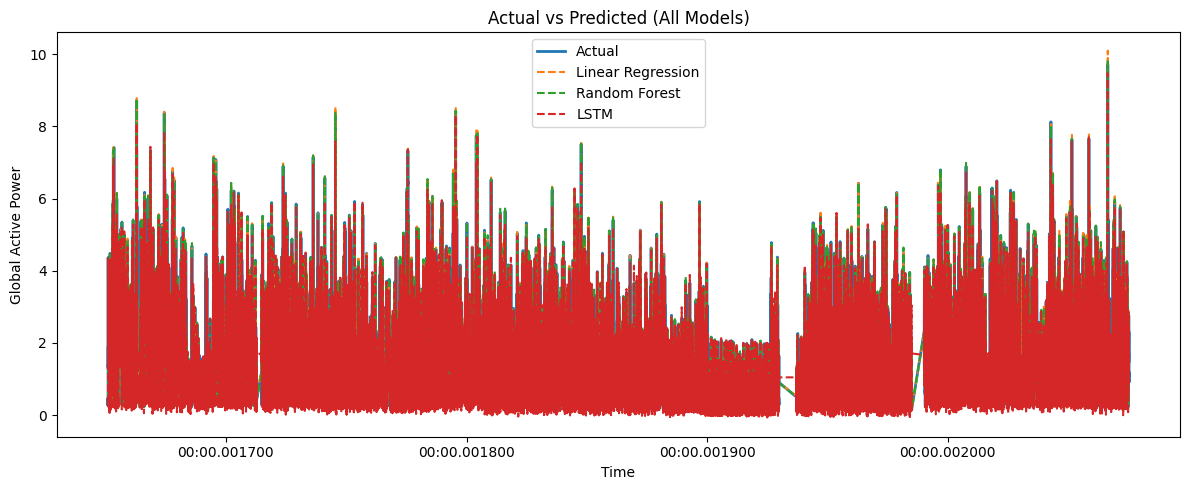

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Actual values
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)

# Model predictions
plt.plot(y_test.index, lr_preds, label='Linear Regression', linestyle='--')
plt.plot(y_test.index, rf_preds, label='Random Forest', linestyle='--')
plt.plot(y_test.index[:len(lstm_preds)], lstm_preds, label='LSTM', linestyle='--')

plt.title('Actual vs Predicted (All Models)')
plt.xlabel('Time')
plt.ylabel('Global Active Power')
plt.legend()
plt.tight_layout()
plt.show()

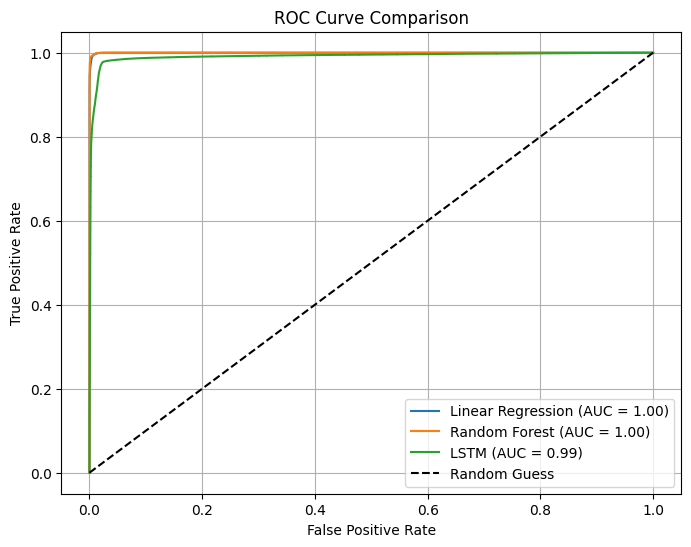

In [ ]:
from sklearn.metrics import roc_curve, auc

# Define classification variables (moved from cell YK9Zlh8fwgUk)
threshold = y_test.median()
y_test_class = (y_test >= threshold).astype(int)
lr_class = (lr_preds >= threshold).astype(int)
rf_class = (rf_preds >= threshold).astype(int)
threshold_lstm = np.median(y_test_lstm)

y_test_lstm_class = (y_test_lstm >= threshold_lstm).astype(int)
lstm_class = (lstm_preds.flatten() >= threshold_lstm).astype(int)

fpr_lr, tpr_lr, _ = roc_curve(y_test_class, lr_preds)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test_class, rf_preds)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_lstm, tpr_lstm, _ = roc_curve(
    y_test_lstm_class,
    lstm_preds.flatten()
)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'Linear Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.2f})')

# Reference line (random classifier)
plt.plot([0,1], [0,1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
threshold = y_test.median()
y_test_class = (y_test >= threshold).astype(int)
lr_class = (lr_preds >= threshold).astype(int)
rf_class = (rf_preds >= threshold).astype(int)
threshold_lstm = np.median(y_test_lstm)

y_test_lstm_class = (y_test_lstm >= threshold_lstm).astype(int)
lstm_class = (lstm_preds.flatten() >= threshold_lstm).astype(int)


•	**Final comparison of Accuracy score, precision score, recall score, f1 score**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
lr_acc = accuracy_score(y_test_class, lr_class)
lr_prec = precision_score(y_test_class, lr_class)
lr_rec = recall_score(y_test_class, lr_class)
lr_f1 = f1_score(y_test_class, lr_class)

rf_acc = accuracy_score(y_test_class, rf_class)
rf_prec = precision_score(y_test_class, rf_class)
rf_rec = recall_score(y_test_class, rf_class)
rf_f1 = f1_score(y_test_class, rf_class)

lstm_acc = accuracy_score(y_test_lstm_class, lstm_class)
lstm_prec = precision_score(y_test_lstm_class, lstm_class)
lstm_rec = recall_score(y_test_lstm_class, lstm_class)
lstm_f1 = f1_score(y_test_lstm_class, lstm_class)

classification_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'Accuracy': [lr_acc, rf_acc, lstm_acc],
    'Precision': [lr_prec, rf_prec, lstm_prec],
    'Recall': [lr_rec, rf_rec, lstm_rec],
    'F1 Score': [lr_f1, rf_f1, lstm_f1]
})

print(classification_results)



               Model  Accuracy  Precision    Recall  F1 Score
0  Linear Regression  0.993280   0.994338  0.992211  0.993273
1      Random Forest  0.994122   0.998041  0.990189  0.994099
2               LSTM  0.500890   0.500473  0.999995  0.667086


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
best_model = classification_results.sort_values(by='F1 Score', ascending=False).iloc[0]
print("Best Classification Model:")
print(best_model)


Best Classification Model:
Model        Random Forest
Accuracy          0.994122
Precision         0.998041
Recall            0.990189
F1 Score          0.994099
Name: 1, dtype: object
